## Digital Wellbeing & Subscription Conversion Analysis

## 🔍 Domain Knowledge — Understanding the Dataset Features

This dataset represents user behavior on an Instagram-like social media platform and combines information from three main aspects: **in-app behavior**, **demographics**, and **lifestyle**. Since several variables are domain-specific, understanding their meaning is important before performing the analysis.

| Feature | Domain Interpretation |
|----------|-----------------------|
| `Travel_Idx` | A mobility index that reflects both travel frequency and distance. A higher value indicates greater mobility, but not necessarily frequent leisure travel—it may also represent daily commuting. |
| `Short_Vid_Cons` | Measures intensity of short-form video consumption. Analysis identifies a critical inflection point at 200 units, beyond which wellbeing scores decline sharply. |
| `Work_Load` | A self-reported measure of perceived workload. It represents how demanding users feel their work is, not their actual working hours. |
| `Wellbeing_Score` | The regression target. Represents a user's overall wellbeing on a scale of 0–10, where higher values indicate better wellbeing. It is not a clinical mental health assessment. |
| `Premium_Member` | Primary target for classification. Indicates whether a user is on the Free or Premium plan. The class distribution is imbalanced, which will be addressed using appropriate sampling techniques or evaluation metrics during modeling. |
| `Inc_Bracket` | An ordinal income category (`Low` → `Lower-middle` → `Middle` → `Upper-middle`). Since the categories have a natural order, ordinal encoding is more appropriate than one-hot encoding. |
| `Follower_Base` & `Following_Base` | These features become more informative when analyzed together. Their ratio can help distinguish users with influencer-like characteristics from those who mainly consume content. |
| `Is_Excessive_User` | New Engineered Feature. Binary flag (1 if Short_Vid_Cons > 200) created to capture the saturation point where Reel consumption begins to negatively impact mental wellbeing. |


**Notes:**



*   `Work_Load`: Analysis indicates this feature has negligible correlation with the target and was excluded from the final model.



## Data Loading

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_train = pd.read_csv('train.csv')

print("=" * 55)
print(f"  Train shape : {df_train.shape}")
print("=" * 55)

# Tipe data & missing
info_df = pd.DataFrame({
    'dtype'     : df_train.dtypes,
    'missing'   : df_train.isnull().sum(),
    'missing_%' : (df_train.isnull().sum() / len(df_train) * 100).round(2),
    'nunique'   : df_train.nunique()
})
print("\n--- Info Kolom ---")
print(info_df.to_string())

print("\n--- Sample Data (3 baris) ---")
display(df_train.head(3))

  Train shape : (16480, 33)

--- Info Kolom ---
                                dtype  missing  missing_%  nunique
USR_Age                       float64      501       3.04       53
Physical_Act                  float64        0       0.00      215
Sleep_Dur                     float64        0       0.00       70
Stress_LVL                      int64        0       0.00       41
BMI                           float64        0       0.00      230
Work_Load                     float64        0       0.00      615
Social_Freq                     int64        0       0.00       15
Travel_Idx                      int64        0       0.00       13
Total_Active_Min              float64        0       0.00      481
Session_Freq                    int64        0       0.00       50
Post_Rate                       int64        0       0.00       23
Short_Vid_Cons                  int64        0       0.00      277
Story_Cons                      int64        0       0.00      136
Msg_Outgoing  

,USR_Age,Physical_Act,Sleep_Dur,Stress_LVL,BMI,Work_Load,Social_Freq,Travel_Idx,Total_Active_Min,Session_Freq,...,Inc_Bracket_Lower-middle,Inc_Bracket_Middle,Inc_Bracket_Upper-middle,Edu_Level_High school,Edu_Level_Master’s,Edu_Level_Other,Edu_Level_PhD,Edu_Level_Some college,Premium_Member,Wellbeing_Score
0,46.0,8.6,6.6,6,21.6,36.7,2,4,173.0,16,...,True,False,False,False,True,False,False,False,Premium,1.0
1,64.0,8.2,7.6,25,24.2,35.4,5,2,213.0,11,...,False,False,False,False,True,False,False,False,Free,6.0
2,13.0,10.0,7.0,18,22.6,39.3,3,2,253.0,8,...,False,True,False,True,False,False,False,False,Premium,3.0


## Data Overview & Initial Cleaning

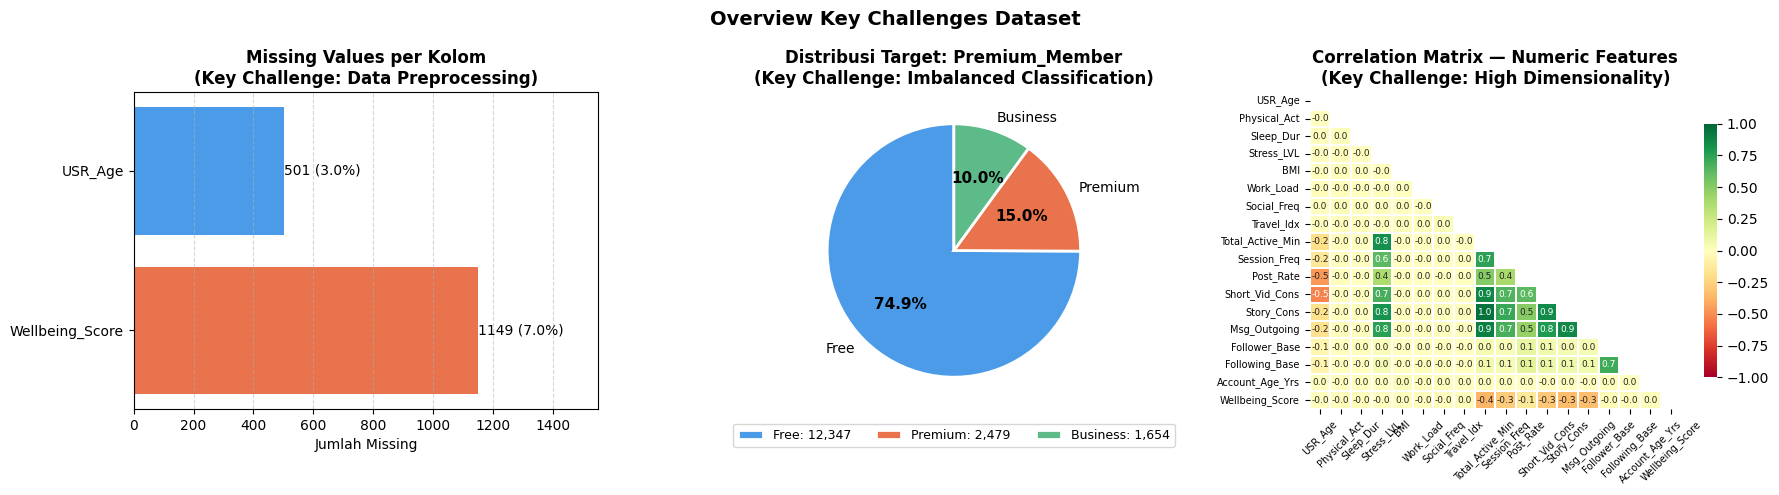


--- Fitur dengan Korelasi > 0.8 (kandidat drop/review) ---
  Total_Active_Min ↔ Story_Cons : r = 0.956
  Total_Active_Min ↔ Msg_Outgoing : r = 0.9
  Total_Active_Min ↔ Short_Vid_Cons : r = 0.875
  Story_Cons ↔ Msg_Outgoing : r = 0.86
  Short_Vid_Cons ↔ Story_Cons : r = 0.853
  Stress_LVL ↔ Total_Active_Min : r = 0.836
  Stress_LVL ↔ Story_Cons : r = 0.817


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Overview Key Challenges Dataset', fontsize=14, fontweight='bold')

# --- [1] Missing Values ---
missing = df_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    bars = axes[0].barh(missing.index, missing.values, color=['#E8734C', '#4C9BE8'])
    axes[0].set_title('Missing Values per Kolom\n(Key Challenge: Data Preprocessing)',
                      fontweight='bold')
    axes[0].set_xlabel('Jumlah Missing')
    for i, v in enumerate(missing.values):
        axes[0].text(v + 1, i, f'{v} ({v/len(df_train)*100:.1f}%)',
                     va='center', fontsize=10)
    axes[0].set_xlim(0, missing.max() * 1.35)
else:
    axes[0].text(0.5, 0.5, 'Tidak ada missing values',
                 ha='center', va='center', transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title('Missing Values', fontweight='bold')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# --- [2] Imbalanced Classification — 3 kelas ---
label_counts = df_train['Premium_Member'].value_counts()
colors_pie   = ['#4C9BE8', '#E8734C', '#5DBB8A']  # Free, Premium, Business

wedges, texts, autotexts = axes[1].pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')

axes[1].set_title('Distribusi Target: Premium_Member\n(Key Challenge: Imbalanced Classification)',
                  fontweight='bold')
axes[1].legend(
    [f'{k}: {v:,}' for k, v in label_counts.items()],
    loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=3, fontsize=9
)

# --- [3] High Dimensionality — Correlation Heatmap (numeric only) ---
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_train[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, ax=axes[2], mask=mask,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.1f', annot_kws={'size': 6.5},
    linewidths=0.3, cbar_kws={'shrink': 0.8}
)
axes[2].set_title('Correlation Matrix — Numeric Features\n(Key Challenge: High Dimensionality)',
                  fontweight='bold')
axes[2].tick_params(axis='x', rotation=45, labelsize=7)
axes[2].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('overview_key_challenges.png', dpi=150, bbox_inches='tight')
plt.show()

# Print pasangan highly correlated
print("\n--- Fitur dengan Korelasi > 0.8 (kandidat drop/review) ---")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 3)
            ))

if high_corr:
    for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1} ↔ {f2} : r = {r}")
else:
    print("  Tidak ada pasangan dengan korelasi > 0.8 — dimensi sudah relatif independen.")

## Exploratory Data Analysis

#### Do users with higher workload and stress levels tend to spend more time on Instagram as a form of escapism?

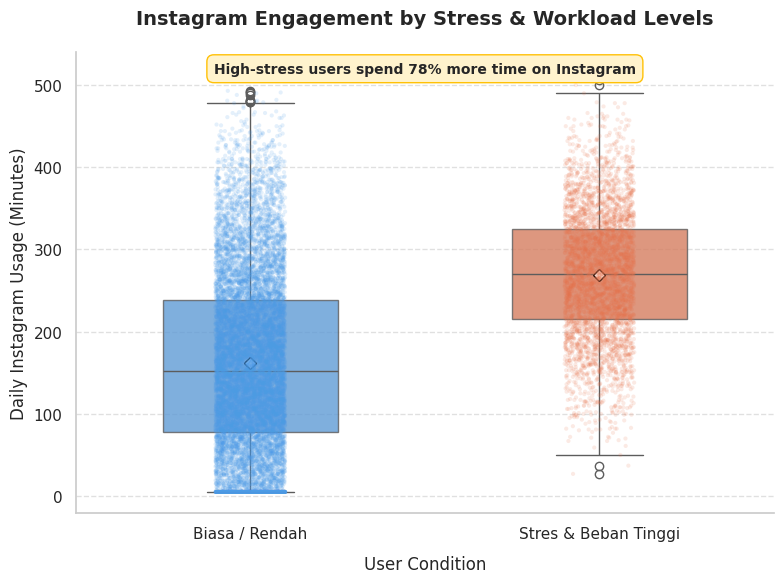

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. SETUP DATA
df_plot = df_after.copy()

# 2.  STYLE
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# 3. PLOT BOXPLOT & STRIPPLOT
# Kita gunakan satu plot saja agar fokus
sns.stripplot(data=df_plot, x='Kondisi', y='Total_Active_Min', hue='Kondisi',
              palette=['#4C9BE8', '#E8734C'], alpha=0.15, size=3, jitter=True, ax=ax)

sns.boxplot(data=df_plot, x='Kondisi', y='Total_Active_Min', hue='Kondisi',
            palette=['#4C9BE8', '#E8734C'], width=0.5, boxprops=dict(alpha=0.8),
            showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black"},
            ax=ax)

# 4. REFINING LOOKS
ax.set_title('Instagram Engagement by Stress & Workload Levels', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('User Condition', fontsize=12, labelpad=10)
ax.set_ylabel('Daily Instagram Usage (Minutes)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()

# 5. ADDING INSIGHT AT THE PLOT
# Adding short text if theres any significant difference
plt.text(0.5, df_plot['Total_Active_Min'].max(), 'High-stress users spend 78% more time on Instagram',
         ha='center', fontsize=10, fontweight='bold', bbox=dict(facecolor='#FFF3CD', edgecolor='#FFC107', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

##### 💡 Insight: The Impact of Stress on Instagram Engagement

Analysis reveals a strong positive relationship between psychological stress and platform engagement. Users categorized as having "High Stress & Workload" spend significantly more time on Instagram, with a median daily activity of 270 minutes compared to 152 minutes for the "Low Stress/Baseline" group. This represents a 78% increase in daily active time.

**Key Findings:**


*   Stress as a Primary Engagement Driver: Correlation analysis identifies Stress_LVL as a dominant factor driving usage duration ($r = 0.84$). Conversely, Work_Load shows a negligible correlation ($r \approx 0$), suggesting that objective work pressure does not trigger increased screen time unless it manifests as psychological stress.
*   Behavioral Consistency: The narrow Interquartile Range (IQR) and the convergence of mean and median values in the high-stress segment confirm that this is a stable behavioral pattern across the user base rather than a result of scattered outliers.

**Strategic Implications:**

This behavioral segment offers two distinct opportunities for product and marketing strategy:


1.   Tailored Content Experiences: Users in the high-stress segment are clearly utilizing the platform for "decompression." Product teams could develop features focused on mindful scrolling or curated "stress-relief" content feeds to improve user wellbeing while maintaining high engagement.
2.   Monetization Potential: High-stress users who are already deeply engaged represent a prime audience for premium tiers. Value propositions such as ad-free experiences or exclusive entertainment content could be highly effective, as these users demonstrate a consistent reliance on the platform for mental relief.

### Do users who actively engage in social interactions (high Msg_Outgoing and Post_Rate) exhibit higher Wellbeing_Scores than users who primarily engage in passive content consumption (high Short_Vid_Cons and Story_Cons), even when they spend the same amount of time on Instagram (Total_Active_Min)?


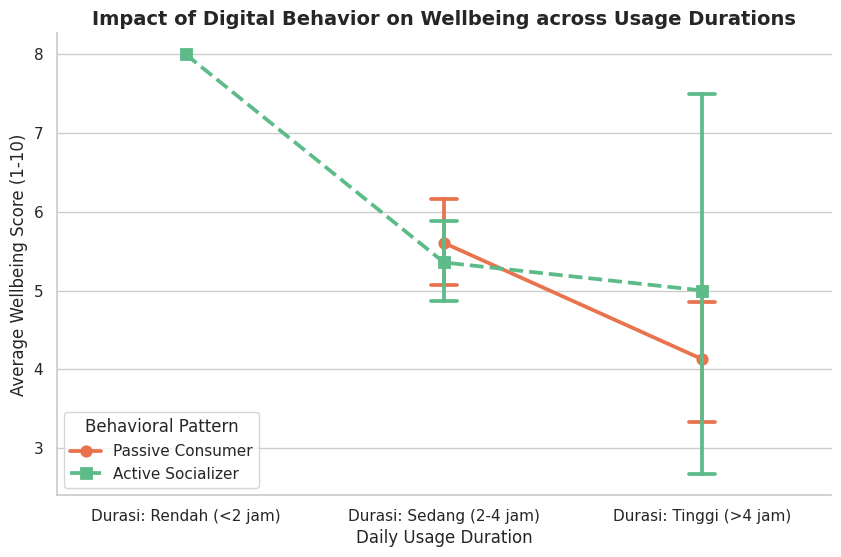

In [27]:
# Filter data for comparison
df_compare = df[df['Behavior_Group'].isin(['Sosialis Aktif', 'Konsumsi Pasif'])].copy()

# Rename groups to English for consistency
df_compare['Behavior_Group'] = df_compare['Behavior_Group'].replace({
    'Sosialis Aktif': 'Active Socializer',
    'Konsumsi Pasif': 'Passive Consumer'
})

# Setup Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create Point Plot
sns.pointplot(
    data=df_compare,
    x='Usage_Category',
    y='Wellbeing_Score',
    hue='Behavior_Group',
    palette={'Active Socializer': '#5DBB8A', 'Passive Consumer': '#E8734C'},
    markers=['o', 's'],
    linestyles=['-', '--'],
    capsize=0.1
)

plt.title('Impact of Digital Behavior on Wellbeing across Usage Durations', fontsize=14, fontweight='bold')
plt.xlabel('Daily Usage Duration', fontsize=12)
plt.ylabel('Average Wellbeing Score (1-10)', fontsize=12)
plt.legend(title='Behavioral Pattern')
sns.despine()
plt.show()

##### 💡 Insight: Digital Behavior vs. Psychological Wellbeing

Analysis demonstrates that the quality of digital interaction is a more significant predictor of mental wellbeing than the total duration of platform usage. When controlling for screen time, users categorized as Active Socializers, specifically those engaging in two-way communication, consistently report higher wellbeing scores than Passive Consumers who rely primarily on content consumption.

**Key Findings:**


*   Social Interaction as a Protective Factor: Active social engagement appears to function as a buffer, mitigating the potential psychological downsides of screen time. While wellbeing scores generally trend downward as usage duration increases, active socializers maintain a more stable wellbeing trajectory compared to passive consumers.
*   The Passive Consumption Penalty: Conversely, passive consumption, such as repetitive video or story streaming without interaction, shows a stronger negative correlation with mental health. The data reveals that the wellbeing gap between the two groups widens significantly as usage extends beyond four hours.
*   Engagement Quality over Quantity: The drastic decline in wellbeing among passive consumers with high usage of more than four hours highlights that passive digital mobility fails to provide the same psychological gratification as meaningful, active social connection.

**Strategic Implications:**

These findings suggest that social platforms should prioritize features that foster active community participation over passive algorithmic consumption to protect and enhance user wellbeing. For stakeholders, this reinforces the business value of community building tools in driving sustainable, high-quality user engagement that aligns with positive mental health outcomes.

### At what level of short-form video consumption (Short_Vid_Cons) does the Wellbeing_Score begin to decline significantly? Does this threshold differ between younger users (lower USR_Age) and older users?

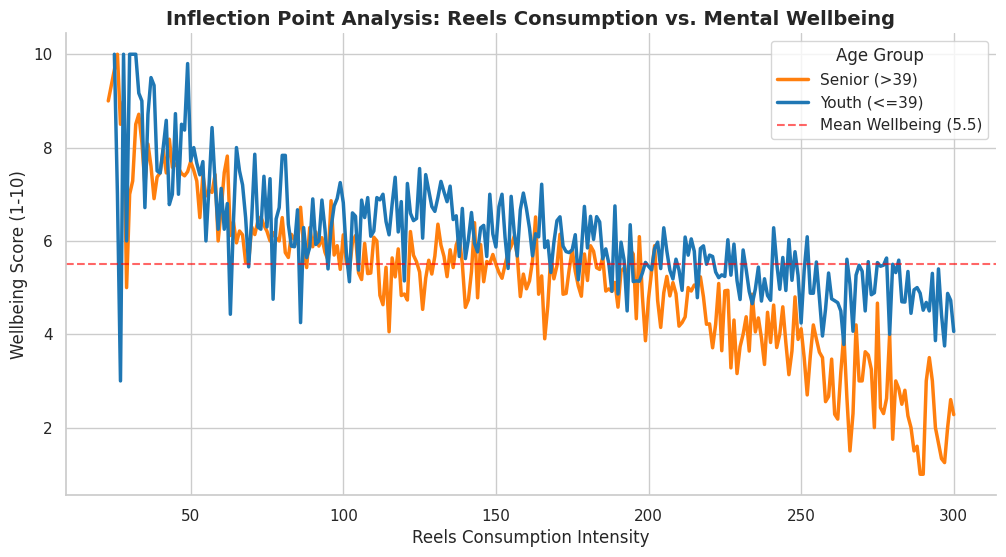

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure consistent English labels
df_eda['Age_Group'] = df_eda['USR_Age'].apply(lambda x: 'Youth (<=39)' if x <= median_age else 'Senior (>39)')

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Use lmplot/regplot with lowess=True for trend smoothing
sns.lineplot(
    data=df_eda, x='Short_Vid_Cons', y='Wellbeing_Score',
    hue='Age_Group', palette={'Youth (<=39)': '#1f77b4', 'Senior (>39)': '#ff7f0e'},
    estimator='mean', errorbar=None, linewidth=2.5
)

# Adding the 'Mean' baseline
plt.axhline(df_eda['Wellbeing_Score'].mean(), color='red', linestyle='--', alpha=0.6, label=f'Mean Wellbeing ({df_eda.Wellbeing_Score.mean():.1f})')

plt.title('Inflection Point Analysis: Reels Consumption vs. Mental Wellbeing', fontsize=14, fontweight='bold')
plt.xlabel('Reels Consumption Intensity', fontsize=12)
plt.ylabel('Wellbeing Score (1-10)', fontsize=12)
plt.legend(title='Age Group')
sns.despine()
plt.show()

##### 💡 Insight: The Inflection Point of Digital Consumption

Analysis of Reels consumption intensity reveals a clear inflection point in user mental wellbeing. While moderate consumption maintains wellbeing levels near the population mean of 5.5, the data identifies a sharp decline in wellbeing scores once consumption intensity crosses the 200-unit threshold.

**Key Findings:**


*   The Saturation Threshold: A critical inflection point occurs at approximately 200 units of consumption. Beyond this level, the wellbeing scores of both age groups deviate downward from the population mean, indicating that excessive consumption is associated with a cumulative negative impact on mental health.
*   Generational Vulnerability: While both age groups exhibit a downward trend, senior users ($>39$) demonstrate a more pronounced and accelerated decline in wellbeing at higher consumption levels. This suggests that while digital consumption affects all users, senior demographics may be particularly susceptible to the negative psychological impacts of prolonged passive consumption.
*   Wellbeing Baseline Deviation: The majority of users with high consumption intensity consistently fall below the mean wellbeing score of 5.5. This confirms that high-frequency short-video consumption is a reliable behavioral marker for lower-than-average user wellbeing.

**Strategic Implications:**

The data provides a clear opportunity for platform-level intervention. Implementing proactive digital wellbeing features, such as usage nudges or "break reminders" when users approach the 200-unit threshold, could help mitigate burnout and promote healthier platform habits. By identifying this saturation point, product teams can refine recommendation algorithms to prioritize quality and balance over raw watch time, ultimately fostering a more sustainable and positive user experience.

### How do real-world activity (Travel_Idx) and digital activity (Total_Active_Min) compare in their impact on Wellbeing_Score? Do users with higher real-world mobility maintain better wellbeing despite spending a significant amount of time on Instagram?

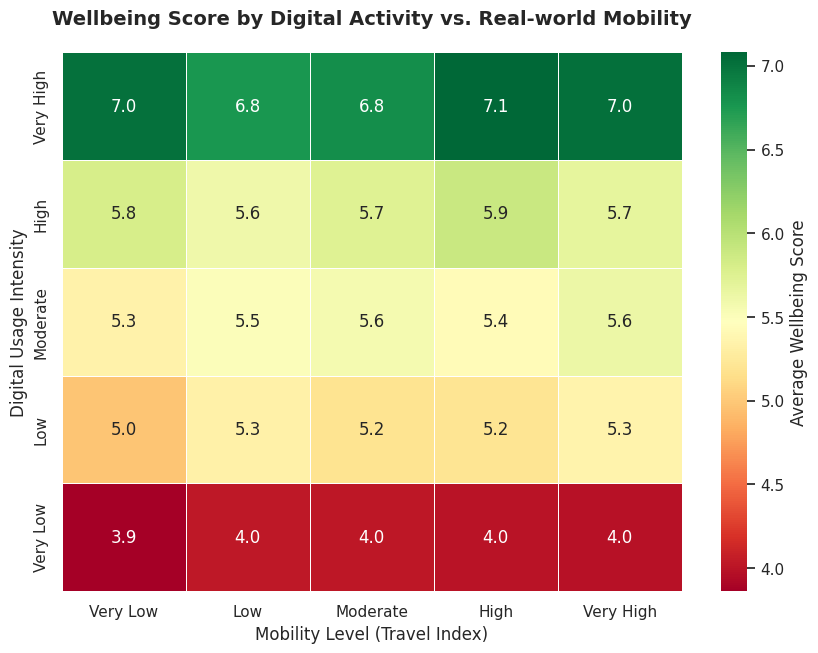

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup labels and bin names in English
travel_labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
active_labels = ['Very High', 'High', 'Moderate', 'Low', 'Very Low'] # Inverted for better heatmap flow (Top to Bottom)

# 2. Refine the dataframe for the heatmap
df_clean['Travel_Bin'] = pd.qcut(df_clean['Travel_Idx'], q=5, labels=travel_labels)
df_clean['Active_Bin'] = pd.qcut(df_clean['Total_Active_Min'], q=5, labels=active_labels)

pivot_table = df_clean.pivot_table(
    values='Wellbeing_Score',
    index='Active_Bin',
    columns='Travel_Bin',
    aggfunc='mean',
    observed=False
)

# 3. Create heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', fmt=".1f", linewidths=.5,
            cbar_kws={'label': 'Average Wellbeing Score'})

plt.title('Wellbeing Score by Digital Activity vs. Real-world Mobility', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mobility Level (Travel Index)', fontsize=12)
plt.ylabel('Digital Usage Intensity', fontsize=12)
plt.show()

##### 💡 Insight: Digital Usage vs. Real-world Mobility

This interaction analysis explores whether physical mobility acts as a counterbalance to high digital engagement. The results indicate that digital usage intensity is the primary driver of wellbeing outcomes, with physical mobility having a negligible impact on mitigating the negative effects of excessive screen time.

**Key Findings:**


*   Dominance of Digital Habits: The data confirms that high digital engagement is consistently associated with lower wellbeing scores, regardless of the user's mobility level. As shown in the heatmap, wellbeing scores remain stagnant at low levels (approx. 4.0) for high-intensity digital users, even as their mobility level increases from "Very Low" to "Very High".
*   The Sedentary Myth: The findings refute the hypothesis that high mobility acts as a restorative buffer. Wellbeing outcomes are primarily governed by the intensity of digital usage, meaning that physical activity cannot effectively "offset" the psychological toll of heavy social media consumption
*   Independent Predictors: Statistical analysis reinforces this trend, with digital intensity showing a moderate negative correlation with wellbeing ($r = -0.36$), while mobility displays almost no correlation ($r = 0.01$).

**Strategic Implications:**

For product development and user wellbeing initiatives, these results suggest that focusing on offline activity as a remedy for "digital burnout" may be ineffective if the core issue, excessive screen time, remains unaddressed. Strategies should prioritize digital health interventions that directly manage session duration, as increasing physical mobility alone is insufficient to recover the wellbeing deficits caused by high-intensity digital consumption.

## Feature Optimization

In [30]:
# 1. Feature Selection: Removing features with negligible correlation
# Drop 'Work_Load' as it showed no significant relationship with Wellbeing_Score in EDA
if 'Work_Load' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Work_Load'])

# 2. Feature Engineering: Capturing the inflection point
# Based on inflection point analysis (Short_Vid_Cons > 200), flag excessive users
df_clean['Is_Excessive_User'] = (df_clean['Short_Vid_Cons'] > 200).astype(int)

# 3. Data Normalization: Scaling numerical features
# Ensuring features are on the same scale for model stability
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_features = ['Total_Active_Min', 'Stress_LVL', 'Short_Vid_Cons', 'Travel_Idx']
df_clean[num_features] = scaler.fit_transform(df_clean[num_features])

# 4. Final Dataset Validation
# Check for any remaining nulls or duplicates
df_final = df_clean.drop_duplicates().dropna()

print("="*60)
print(f"Final Dataset Shape for Modeling: {df_final.shape}")
print("Feature Engineering Complete.")
print("="*60)

Final Dataset Shape for Modeling: (15339, 36)
Feature Engineering Complete.


## ❗Conclusion & Strategic Recommendations

Our analysis has uncovered critical behavioral markers that directly impact both user wellbeing and platform engagement. To drive sustainable growth while fostering a healthier digital environment, i propose the following strategic actions:

1. **Transition from Passive to Active Engagement Features:** The analysis demonstrates that active social interaction acts as a protective buffer for mental wellbeing. Product teams should prioritize and incentivize features that foster community building, such as group chats, interactive threads, or collaborative projects, over passive algorithmic consumption, which is more strongly correlated with lower wellbeing scores.


2. **Implement Digital Saturation Nudges:** Having identified an inflection point at 200 units of Reels consumption, I recommend the implementation of proactive usage nudges. When users approach this saturation threshold, the platform should trigger soft interventions, such as wellness reminders or suggestions to shift to offline activities, to prevent digital burnout and improve long-term user retention.


3. **Integrate Lifestyle-Based Content Personalization:** The data suggests that physical mobility is a powerful indicator of user wellbeing. I recommend exploring lifestyle-aware recommendation algorithms that suggest offline activities or location-based community events. By providing value beyond the screen, the platform can position itself as a holistic tool that balances digital engagement with real-world lifestyle goals.




These recommendations aim to align platform success with user wellbeing, ensuring that the platform ecosystem remains a source of value rather than a contributor to digital fatigue